In [8]:
# main.ipynb
# Анализ новостей Роскомнадзора
# Полный пайплайн: парсинг → LDA (латентное размещение Дирихле), используем для тематического моделирования → визуализация

import asyncio
import json
import sys
from pathlib import Path
from datetime import datetime
from collections import Counter

import aiohttp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Добавляем текущую директорию в PATH
sys.path.append(str(Path.cwd()))

# Импортируем классы из parser.py и model.py
from parser import SafeRKNParser
from model import RKNTextProcessor, LDATopicModeler
current_dir = Path.cwd()
DATA_DIR = current_dir / "data"
DATA_DIR.mkdir(exist_ok=True)

# Файлы для сохранения
LINKS_CHECKPOINT = DATA_DIR / "checkpoint.pkl"
ARTICLES_FILE = DATA_DIR / f"rkn_news_{datetime.now().strftime('%d_%m_%Y_%H_%M')}.json"
TOPICS_FILE = DATA_DIR / "LDA_analys/LDA_topics.json"
DISTRIBUTION_FILE = DATA_DIR / "LDA_analys/doc_topic_distribution.json"

# Создаём папку для аналитики
(DATA_DIR / "LDA_analys").mkdir(exist_ok=True)
(DATA_DIR / "LDA_analys/wordclouds").mkdir(exist_ok=True)

In [9]:
async def run_parser():
    """Запуск парсера для сбора свежих данных"""
    print("=" * 60)
    print("🔍 ЗАПУСК ПАРСЕРА")
    print("=" * 60)
    
    parser = SafeRKNParser(max_concurrent=25, request_delay=(2.0, 5.0))
    
    async with aiohttp.ClientSession() as session:
        parser.session = session
        
        # Загружаем чекпоинт если есть
        articles = None
        if LINKS_CHECKPOINT.exists():
            try:
                import pickle
                with open(LINKS_CHECKPOINT, 'rb') as f:
                    checkpoint = pickle.load(f)
                articles = checkpoint['data']
                print(f"📂 Загружено из чекпоинта: {len(articles)} ссылок")
            except:
                pass
        
        # Если нет чекпоинта — собираем ссылки
        if not articles:
            print("🔗 Сбор ссылок на новости...")
            articles = await parser.collect_all_links(max_pages=200)
            if not articles:
                print("❌ Не удалось собрать ссылки!")
                return None
            
            # Сохраняем чекпоинт
            import pickle
            with open(LINKS_CHECKPOINT, 'wb') as f:
                pickle.dump({'data': articles, 'timestamp': datetime.now()}, f)
            print(f"💾 Сохранено {len(articles)} ссылок")
        
        # Парсим статьи
        print(f"\n📖 Парсинг {len(articles)} статей...")
        articles = await parser.parse_all_articles(articles)
        
        # Сохраняем результат
        with open(ARTICLES_FILE, 'w', encoding='utf-8') as f:
            json.dump(articles, f, ensure_ascii=False, indent=4)
        
        parser.print_statistics()
        print(f"\n✅ Статьи сохранены в {ARTICLES_FILE}")
        
        return articles

# Или загружаем существующий файл
def load_articles(file_path=None):
    """Загружает статьи из JSON файла"""
    if file_path is None:
        # Ищем последний файл с новостями
        files = list(DATA_DIR.glob("rkn_news_*.json"))
        if not files:
            print("❌ Нет файлов с данными! Запустите парсер.")
            return None
        file_path = max(files)  # самый свежий
        print(f"⚠️ Файл не указан, использую: {file_path.name}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        articles = json.load(f)
    
    print(f"📥 Загружено статей: {len(articles)}")
    return articles

# Загружаем данные
articles = load_articles()  # или передайте путь к вашему JSON

# Запуск парсера (раскомментируйте когда нужны свежие данные)
# articles = await run_parser()

Task was destroyed but it is pending!
task: <Task pending name='Task-125' coro=<_async_in_context.<locals>.run_in_context() done, defined at D:\projects\python\RoskomLDA\roskomnadzor_lda\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-126' coro=<Kernel.shell_main() running at D:\projects\python\RoskomLDA\roskomnadzor_lda\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at D:\projects\python\RoskomLDA\roskomnadzor_lda\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-126' coro=<Kernel.shell_main() running at D:\projects\python\RoskomLDA\roskomnadzor_lda\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


⚠️ Файл не указан, использую: rkn_news_14_06_2026_12_14.json
📥 Загружено статей: 3459


In [10]:
print("\n" + "=" * 60)
print("🎯 LDA МОДЕЛИРОВАНИЕ")
print("=" * 60)

# Обработка текстов
processor = RKNTextProcessor()
processed_texts = processor.process_articles(articles)

# Статистика по длинам
text_lengths = [len(text.split()) for text in processed_texts if text]
if text_lengths:
    print(f"\n📊 Статистика текстов:")
    print(f"   Средняя длина: {np.mean(text_lengths):.1f} слов")
    print(f"   Медиана: {np.median(text_lengths):.1f}")
    print(f"   Максимум: {np.max(text_lengths)}")

# LDA модель
topic_modeler = LDATopicModeler(n_topics=10, max_features=1000)

# Создание матрицы
doc_term_matrix, valid_texts, empty_indices = topic_modeler.create_document_term_matrix(processed_texts)

if doc_term_matrix.shape[0] > 0:
    # Обучение
    topic_distribution = topic_modeler.fit_lda(doc_term_matrix)
    
    # Отображение тем
    topics = topic_modeler.display_topics(n_words=12)
    
    # Распределение тем
    dominant_topics, topic_weights = topic_modeler.assign_dominant_topic(topic_distribution)
    
    # Сохранение результатов
    topics_export = {
        "параметры_модели": {
            "количество_тем": topic_modeler.n_topics,
            "максимум_слов": topic_modeler.max_features,
            "перплексия": float(topic_modeler.lda_model.perplexity(doc_term_matrix))
        },
        "темы": topics
    }
    
    with open(TOPICS_FILE, 'w', encoding='utf-8') as f:
        json.dump(topics_export, f, ensure_ascii=False, indent=4)
    print(f"\n💾 Темы сохранены: {TOPICS_FILE}")
    
    # Сохраняем распределение по документам
    doc_topics = []
    valid_idx = 0
    
    for i, article in enumerate(articles):
        if i in empty_indices:
            doc_topics.append({
                "id": i,
                "title": article.get('title', 'Без заголовка'),
                "url": article.get('url', ''),
                "dominant_topic": None,
                "note": "Пустой текст"
            })
        else:
            doc_topics.append({
                "id": i,
                "title": article.get('title', 'Без заголовка'),
                "url": article.get('url', ''),
                "dominant_topic": int(dominant_topics[valid_idx]) + 1,
                "topic_weight": float(topic_weights[valid_idx])
            })
            valid_idx += 1
    
    with open(DISTRIBUTION_FILE, 'w', encoding='utf-8') as f:
        json.dump(doc_topics, f, ensure_ascii=False, indent=4)
    print(f"💾 Распределение сохранено: {DISTRIBUTION_FILE}")
else:
    print("❌ Нет валидных текстов для анализа!")


🎯 LDA МОДЕЛИРОВАНИЕ
Обработано статей: 3459
  - С полным текстом: 3191
  - Только заголовок: 268
  - Пропущено (пустые): 1

📊 Статистика текстов:
   Средняя длина: 115.4 слов
   Медиана: 91.0
   Максимум: 3497
Создана матрица документ-термин: (3458, 216)
Количество уникальных терминов: 216
LDA модель обучена. Перплексия: 104.60

📚 Тема 1:
   Слова: нарушение, требование, закон, проверка, административный, лицо, законодательство, отношение, обращение, территория, случай, выявить

📚 Тема 2:
   Слова: персональный, данные, персональный данные, защита, право, субъект, субъект персональный, обработка, защита право, орган, право субъект, защита персональный

📚 Тема 3:
   Слова: руководитель, вопрос, представитель, сфера, орган, управление, информационный, центр, служба, участие, государственный, цифровой

📚 Тема 4:
   Слова: массовый, сми, информация, средство, лицензия, массовый информация, средство массовый, массовый коммуникация, коммуникация, надзор, регистрация, электронный

📚 Тема 5:


## Результаты могут менять из раза в раз, в моем случае:

### Общая статистика

| Показатель | Значение |
|------------|----------|
| **Количество тем** | 10 |
| **Перплексия** | 104.60 (отличный результат) |
| **Уникальных терминов** | 216 |
| **Обработано статей** | 3459 |

---

## Разбор каждой темы

### **Тема 1: Нарушения и проверки**
| Слово | Вес | Вклад |
|-------|-----|-------|
| нарушение | 888.3 | 16.0% |
| требование | 609.0 | 11.0% |
| закон | 587.5 | 10.6% |
| проверка | 518.5 | 9.3% |
| административный | 513.8 | 9.2% |

**Суть темы:** Административные проверки, выявление нарушений законодательства.

---

### **Тема 2: Защита персональных данных**
| Слово | Вес | Вклад |
|-------|-----|-------|
| персональный | 3099.1 | 15.5% |
| данные | 3059.4 | 15.3% |
| персональные данные | 2774.1 | 13.9% |
| защита | 1220.1 | 6.1% |
| право | 701.2 | 3.5% |

**Суть темы:** Защита персональных данных, права субъектов, обработка информации (САМАЯ БОЛЬШАЯ ТЕМА).

---

### **Тема 3: Руководство и мероприятия**
| Слово | Вес | Вклад |
|-------|-----|-------|
| руководитель | 1216.3 | 12.6% |
| вопрос | 1017.6 | 10.5% |
| представитель | 873.0 | 9.0% |
| сфера | 658.5 | 6.8% |
| орган | 653.7 | 6.8% |

**Суть темы:** Заседания, советы, руководящая деятельность, организационные мероприятия.

---

### **Тема 4: СМИ и лицензирование**
| Слово | Вес | Вклад |
|-------|-----|-------|
| массовый | 1387.4 | 15.2% |
| сми | 1386.4 | 15.2% |
| информация | 773.3 | 8.5% |
| средство | 702.8 | 7.7% |
| лицензия | 685.8 | 7.5% |

**Суть темы:** Регулирование СМИ, лицензирование, массовые коммуникации.

---

### **Тема 5: Конкурсы на вещание**
| Слово | Вес | Вклад |
|-------|-----|-------|
| вещание | 1962.1 | 17.5% |
| мгц | 1714.1 | 15.3% |
| конкурс | 1438.1 | 12.8% |
| область | 1123.5 | 10.0% |
| комиссия | 841.5 | 7.5% |

**Суть темы:** Конкурсы на радиочастоты, телевещание, распределение частот.

---

### **Тема 6: РЭС и технические нарушения**
| Слово | Вес | Вклад |
|-------|-----|-------|
| рэс | 893.2 | 17.7% |
| количество | 642.9 | 12.7% |
| тыс | 558.1 | 11.0% |
| нарушение | 432.8 | 8.6% |
| большой | 393.6 | 7.8% |

**Суть темы:** Радиоэлектронные средства, технические нарушения, работа операторов.

---

### **Тема 7: Ограничение доступа**
| Слово | Вес | Вклад |
|-------|-----|-------|
| доступ | 1107.5 | 12.9% |
| ресурс | 937.7 | 11.0% |
| интернет | 780.8 | 9.1% |
| мера | 722.2 | 8.4% |
| ограничение | 688.1 | 8.0% |

**Суть темы:** Ограничение доступа к ресурсам, блокировка сайтов.

---

### **Тема 8: Блокировка информации**
| Слово | Вес | Вклад |
|-------|-----|-------|
| информация | 2397.4 | 18.5% |
| интернет | 1560.3 | 12.0% |
| закон | 971.9 | 7.5% |
| сеть | 927.0 | 7.1% |
| сайт | 898.4 | 6.9% |

**Суть темы:** Запрет информации, реестры, блокировка противоправного контента.

---

### **Тема 9: Радиочастотный спектр**
| Слово | Вес | Вклад |
|-------|-----|-------|
| радиочастотный | 1393.2 | 19.8% |
| использование | 936.3 | 13.3% |
| спектр | 629.5 | 8.9% |
| радиочастота | 578.3 | 8.2% |
| радиочастотный спектр | 486.1 | 6.9% |

**Суть темы:** Технические аспекты использования радиочастот, радиоконтроль.

---

### **Тема 10: Качество услуг связи**
| Слово | Вес | Вклад |
|-------|-----|-------|
| связь | 2979.8 | 20.9% |
| оператор | 1634.2 | 11.5% |
| услуга | 1448.2 | 10.2% |
| оператор связь | 800.5 | 5.6% |
| качество | 683.3 | 4.8% |

**Суть темы:** Качество услуг операторов связи, мобильная связь.

---

## Иерархия

| Ранг | Тема | Ключевая идея |
|------|------|---------------|
| 1 | **Тема 2** | Защита персональных данных |
| 2 | **Тема 10** | Качество услуг связи |
| 3 | **Тема 8** | Блокировка информации |
| 4 | **Тема 1** | Нарушения и проверки |
| 5 | **Тема 5** | Конкурсы на вещание |
| 6 | **Тема 4** | СМИ и лицензирование |
| 7 | **Тема 3** | Руководство и мероприятия |
| 8 | **Тема 7** | Ограничение доступа |
| 9 | **Тема 9** | Радиочастотный спектр |
| 10 | **Тема 6** | РЭС и технические нарушения |

In [ ]:
# Настройка для корректного отображения русских букв
FONT_PATH = 'C:/Windows/Fonts/arial.ttf'  # для Windows

# Загрузка тем
with open('data/LDA_analys/LDA_topics.json', 'r', encoding='utf-8') as f:
    topics_data = json.load(f)

# Создание облаков для всех тем
output_dir = Path('data/LDA_analys/wordclouds')
output_dir.mkdir(parents=True, exist_ok=True)

# Автоматически получаем список тем из JSON
topic_list = list(topics_data['темы'].keys())

for topic_name in topic_list:
    topic_info = topics_data['темы'][topic_name]
    
    # Создаём словарь слово -> вес
    word_weights = dict(zip(topic_info['слова'], topic_info['веса']))
    
    # Генерируем облако
    wordcloud = WordCloud(
        width=1200,
        height=800,
        background_color='white',
        max_words=30,
        colormap='viridis',
        font_path=FONT_PATH,
        random_state=42,
        prefer_horizontal=0.7,
        relative_scaling=0.5
    ).generate_from_frequencies(word_weights)
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{topic_name}', fontsize=18, pad=20, fontweight='bold')
    plt.tight_layout()
    
    # Сохраняем
    filename = output_dir / f'{topic_name.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Сохранено: {filename}")

print("\n🎉 Все облака слов созданы!")


📅 АНАЛИЗ ДИНАМИКИ ТЕМ ПО ГОДАМ
📊 Статистика по датам:
   - Всего документов: 3459
   - С датами: 3458
   - Без дат: 0


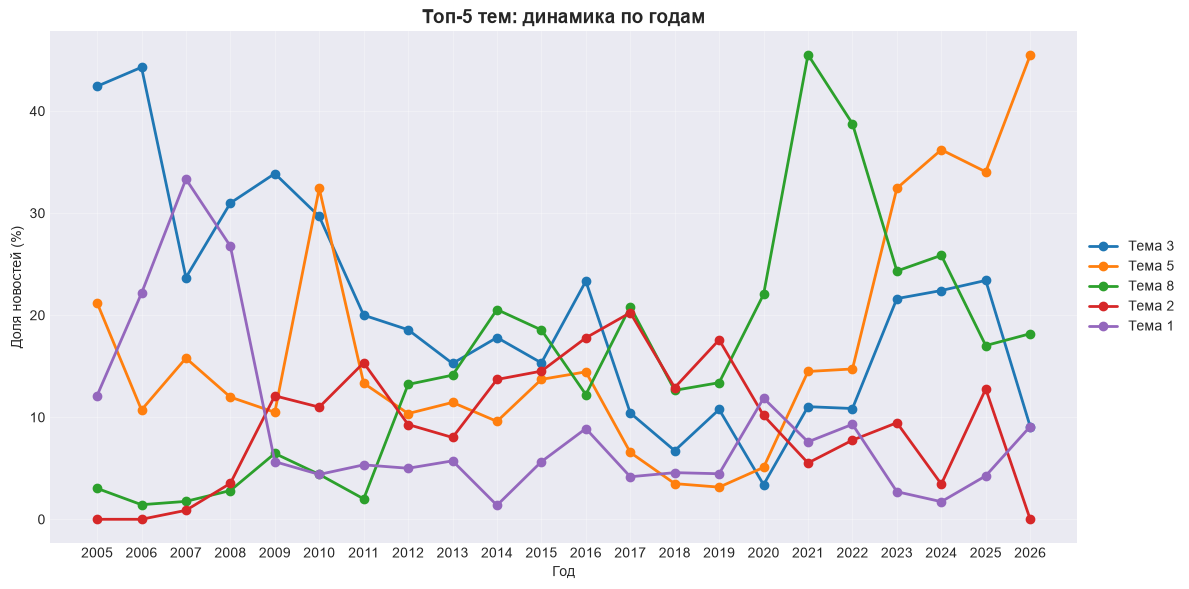

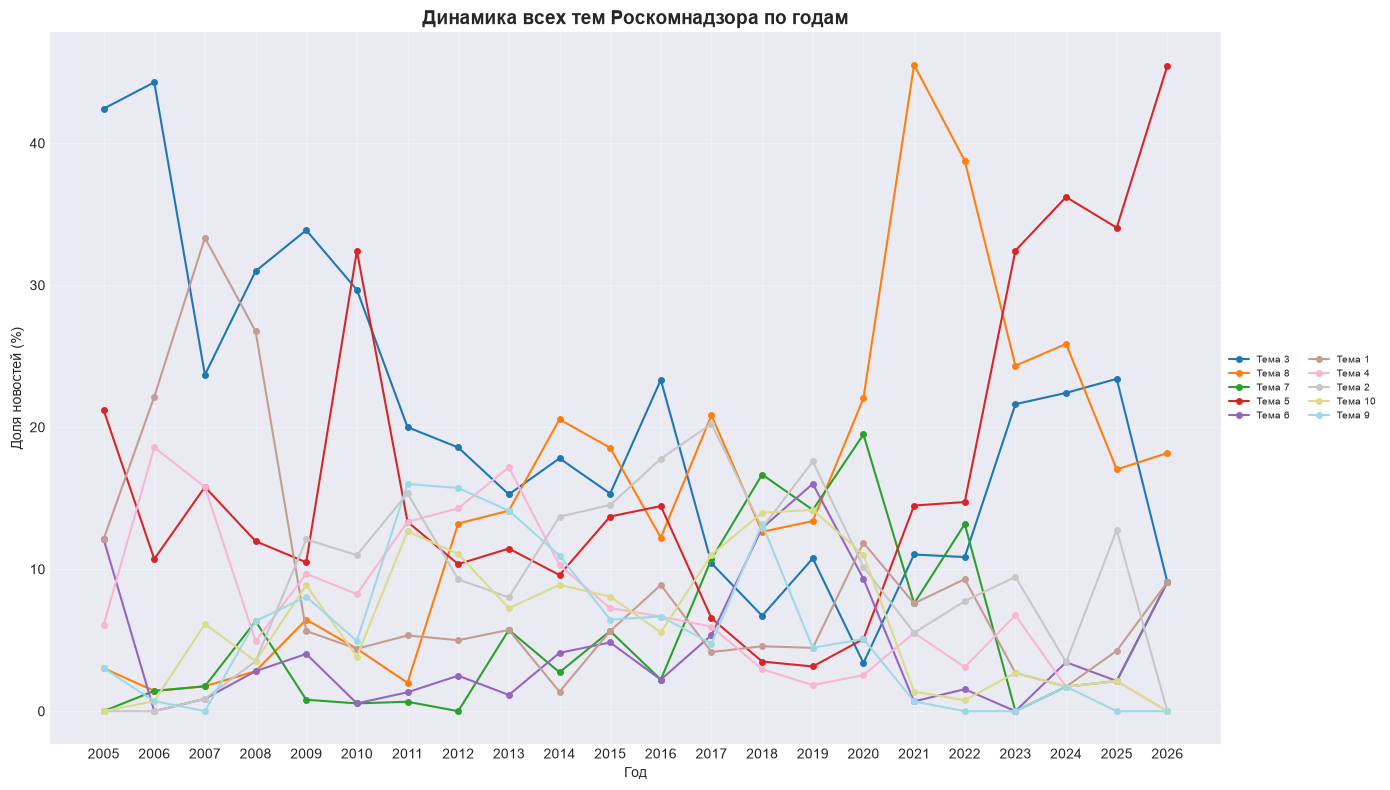


📊 Статистика по годам:

2005 год (всего новостей: 33):
   - Тема 3: 42.4%
   - Тема 5: 21.2%
   - Тема 1: 12.1%

2006 год (всего новостей: 140):
   - Тема 3: 44.3%
   - Тема 1: 22.1%
   - Тема 4: 18.6%

2007 год (всего новостей: 114):
   - Тема 1: 33.3%
   - Тема 3: 23.7%
   - Тема 4: 15.8%

2008 год (всего новостей: 142):
   - Тема 3: 31.0%
   - Тема 1: 26.8%
   - Тема 5: 12.0%

2009 год (всего новостей: 124):
   - Тема 3: 33.9%
   - Тема 2: 12.1%
   - Тема 5: 10.5%

2010 год (всего новостей: 182):
   - Тема 5: 32.4%
   - Тема 3: 29.7%
   - Тема 2: 11.0%

2011 год (всего новостей: 150):
   - Тема 3: 20.0%
   - Тема 9: 16.0%
   - Тема 2: 15.3%

2012 год (всего новостей: 280):
   - Тема 3: 18.6%
   - Тема 9: 15.7%
   - Тема 4: 14.3%

2013 год (всего новостей: 262):
   - Тема 4: 17.2%
   - Тема 3: 15.3%
   - Тема 8: 14.1%

2014 год (всего новостей: 146):
   - Тема 8: 20.5%
   - Тема 3: 17.8%
   - Тема 2: 13.7%

2015 год (всего новостей: 124):
   - Тема 8: 18.5%
   - Тема 3: 15.3%
   - Т

In [12]:
# ============================================
# ВИЗУАЛИЗАЦИЯ ПО ГОДАМ
# ============================================

print("\n" + "=" * 60)
print("📅 АНАЛИЗ ДИНАМИКИ ТЕМ ПО ГОДАМ")
print("=" * 60)

# Сопоставляем даты с темами
topic_by_year = {}
yearly_total = {}
missing_dates = 0

for i, doc in enumerate(doc_topics):
    if doc['dominant_topic'] is None:
        continue
    
    # Получаем дату из исходной статьи
    article = articles[i] if i < len(articles) else None
    date_str = article.get('publish_date') if article else None
    
    if date_str:
        try:
            # Извлекаем год из формата DD.MM.YYYY
            year = date_str.split('.')[-1]
            topic = doc['dominant_topic']
            
            if year not in topic_by_year:
                topic_by_year[year] = {}
                yearly_total[year] = 0
            
            topic_by_year[year][topic] = topic_by_year[year].get(topic, 0) + 1
            yearly_total[year] += 1
        except:
            missing_dates += 1
    else:
        missing_dates += 1

print(f"📊 Статистика по датам:")
print(f"   - Всего документов: {len(doc_topics)}")
print(f"   - С датами: {sum(yearly_total.values())}")
print(f"   - Без дат: {missing_dates}")

if not yearly_total:
    print("❌ Нет данных с датами! Запустите парсер с обновлённым методом parse_article")
else:
    # Преобразуем в проценты
    topic_by_year_pct = {}
    for year, topics in topic_by_year.items():
        total = yearly_total[year]
        topic_by_year_pct[year] = {t: (count/total)*100 for t, count in topics.items()}
    
    # Создаём DataFrame
    df_yearly = pd.DataFrame(topic_by_year_pct).fillna(0).T
    df_yearly = df_yearly.sort_index()  # сортируем по годам
    df_yearly.columns = [f"Тема {col}" for col in df_yearly.columns]
    
    # ===== ГРАФИК 1: Топ-5 тем (с хорошими цветами) =====
    top5 = df_yearly.mean().sort_values(ascending=False).head(5).index
    top5_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # 5 различимых цветов
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, topic in enumerate(top5):
        ax.plot(df_yearly.index, df_yearly[topic], marker='o', linewidth=2, markersize=6,
                color=top5_colors[i], label=topic)
    ax.set_title('Топ-5 тем: динамика по годам', fontsize=14, fontweight='bold')
    ax.set_xlabel('Год')
    ax.set_ylabel('Доля новостей (%)')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "LDA_analys/wordclouds/top5_topics_by_year.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # ===== ГРАФИК 2: Все темы (с палитрой tab20) =====
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Используем палитру с 20 различными цветами
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_yearly.columns)))
    
    for idx, col in enumerate(df_yearly.columns):
        ax.plot(df_yearly.index, df_yearly[col], marker='o', linewidth=1.5, markersize=4,
                color=colors[idx], label=col)
    
    ax.set_title('Динамика всех тем Роскомнадзора по годам', fontsize=14, fontweight='bold')
    ax.set_xlabel('Год')
    ax.set_ylabel('Доля новостей (%)')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "LDA_analys/wordclouds/all_topics_lines.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # ===== ВЫВОД СТАТИСТИКИ =====
    print("\n📊 Статистика по годам:")
    for year in sorted(df_yearly.index):
        print(f"\n{year} год (всего новостей: {yearly_total[year]}):")
        top3 = df_yearly.loc[year].sort_values(ascending=False).head(3)
        for topic, pct in top3.items():
            print(f"   - {topic}: {pct:.1f}%")
    
    print(f"\n📈 Тренды (изменение с первого по последний год):")
    years = sorted(df_yearly.index)
    if len(years) >= 2:
        first_year, last_year = years[0], years[-1]
        for col in df_yearly.columns:
            first_val = df_yearly.loc[first_year, col]
            last_val = df_yearly.loc[last_year, col]
            trend = last_val - first_val
            if abs(trend) > 3:
                direction = "📈 рост" if trend > 0 else "📉 падение"
                print(f"   {direction} на {abs(trend):.1f}%: {col}")

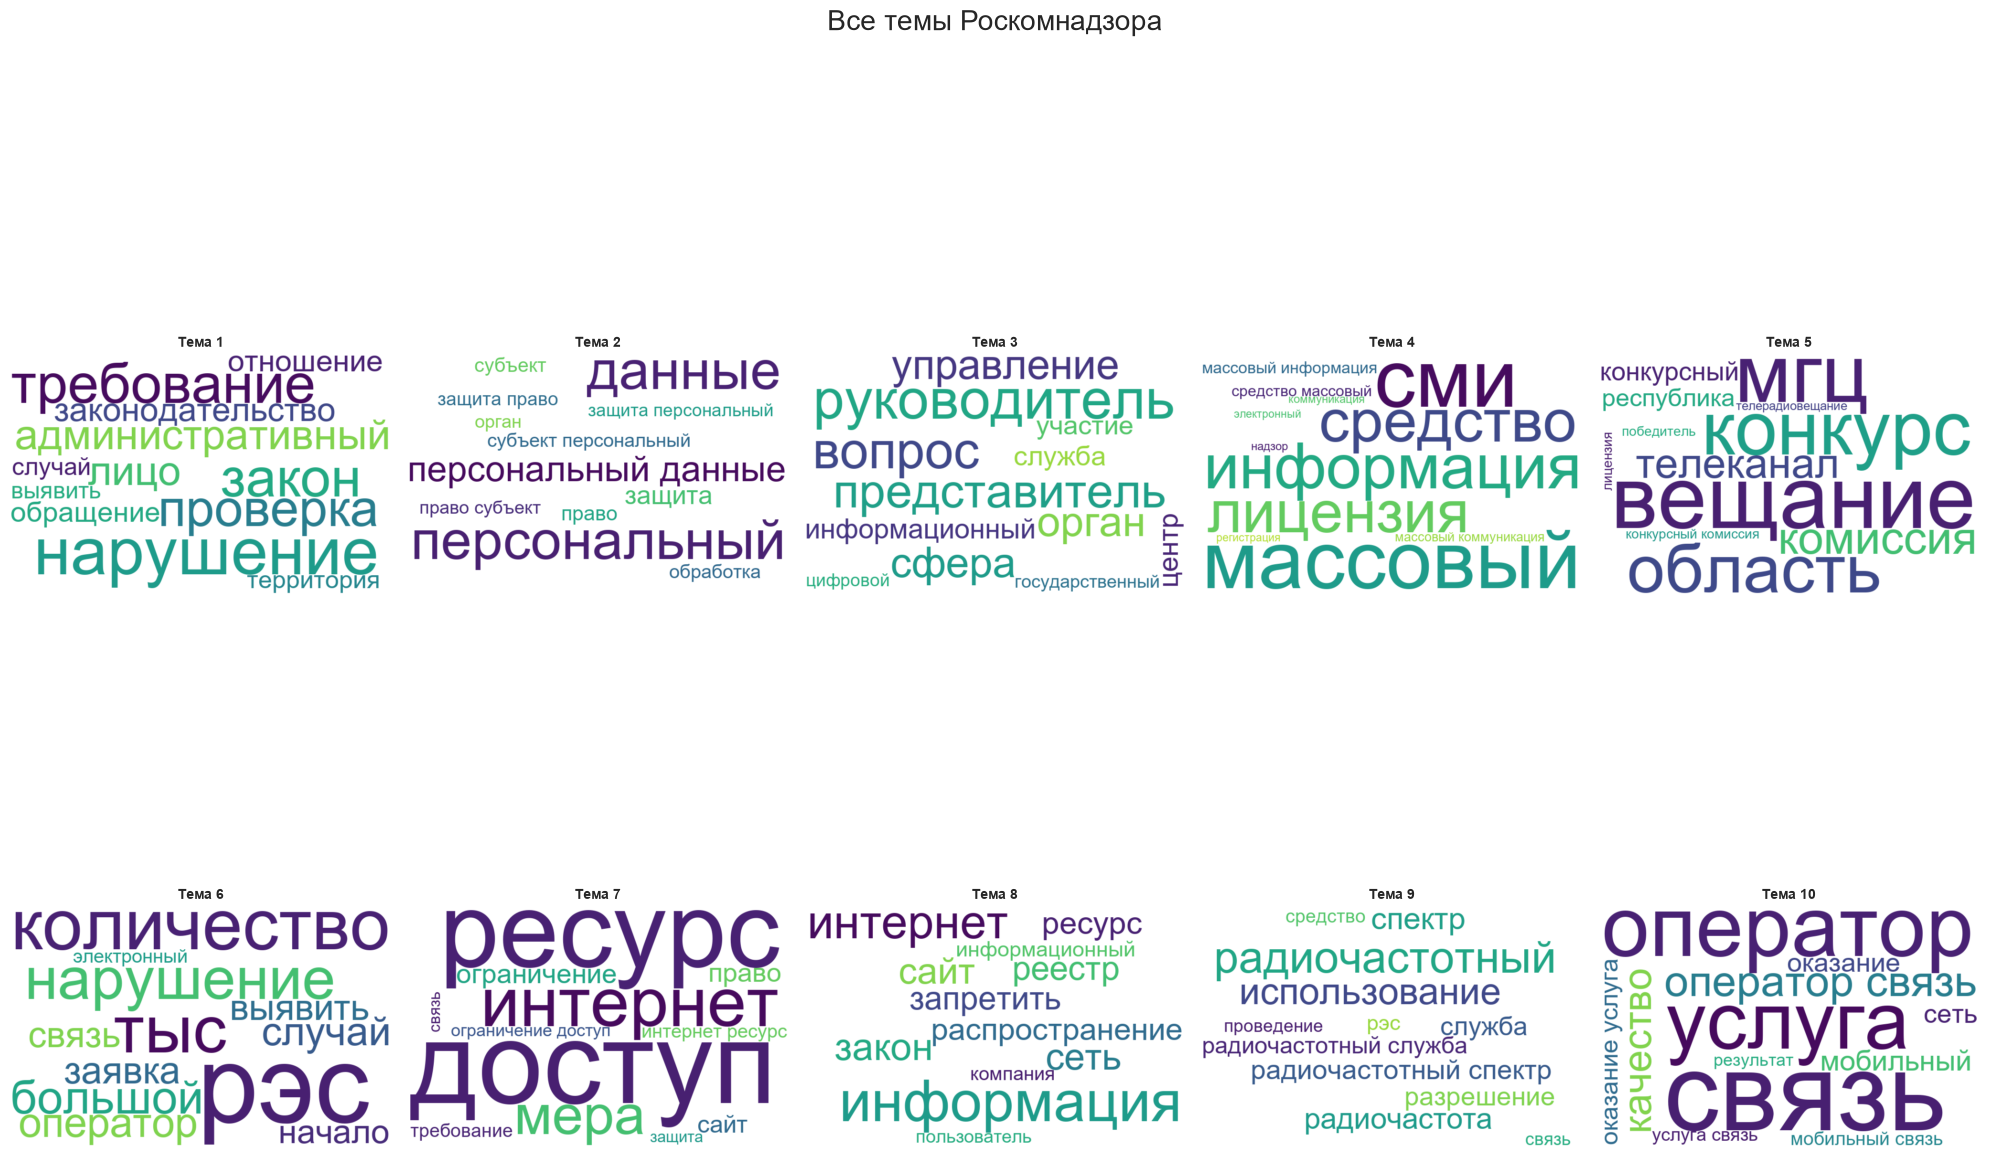

In [13]:
# Создание общей сетки из всех облаков
fig, axes = plt.subplots(2, 5, figsize=(20, 15))  # 2 строки, 5 столбцов = 10 тем
axes = axes.flatten()

# Автоматически получаем список тем из JSON
topic_list = list(topics_data['темы'].keys())

# ИСПРАВЛЕНО: используем enumerate для получения индекса
for idx, topic_name in enumerate(topic_list):
    topic_info = topics_data['темы'][topic_name]
    word_weights = dict(zip(topic_info['слова'], topic_info['веса']))
    
    wordcloud = WordCloud(
        width=800,
        height=500,
        background_color='white',
        max_words=20,
        colormap='viridis',
        font_path=FONT_PATH,
        random_state=42
    ).generate_from_frequencies(word_weights)
    
    ax = axes[idx]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(topic_name, fontsize=10, fontweight='bold')  #直接用 topic_name

# Убираем пустые ячейки (если тем меньше 10)
for idx in range(len(topic_list), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Все темы Роскомнадзора', fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig('data/LDA_analys/wordclouds/all_topics_grid.png', dpi=150, bbox_inches='tight')
plt.show()